In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder # for labels {1,0,2,...}
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import sys
import os 
sys.path.append(os.path.abspath(".."))
from src.Linear_Model.Logestic_Regression import LogisticRegression



In [2]:
df=pd.read_csv('../data/Titanic-Dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


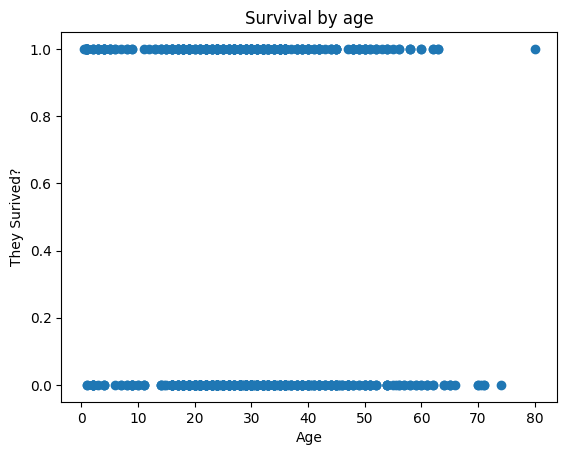

In [3]:
# as we can see Age isn't a Good estimate of survival but we can't ignore the Ladies and Childeren First
plt.scatter(x='Age',y='Survived',data=df)
plt.xlabel("Age")
plt.ylabel("They Surived?")
plt.title("Survival by age")
plt.show()

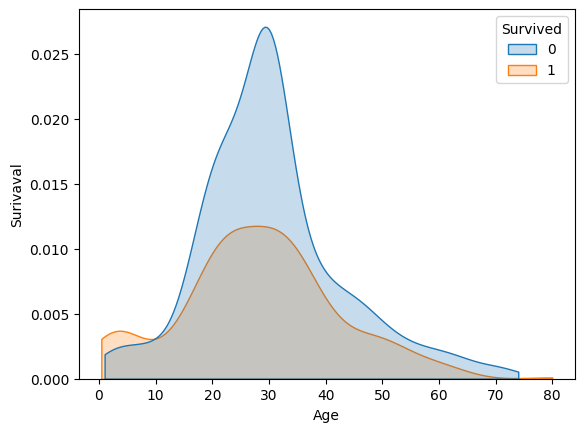

In [4]:
#cleaning the Data by filling the giving the median value for the null values of Age by seeing their names
df['Title']=df['Name'].str.extract(r"([A-Za-z]+)\.",expand=False)
df['Title'].replace(['Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'],"Rare")
df['Title'] = df['Title'].replace(['Mlle','Lady','Countess'], 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

df['Age']=df['Age'].fillna(df.groupby('Title')['Age'].transform('median'))

sns.kdeplot(data=df, x='Age', hue='Survived', fill=True,cut=0)
plt.xlabel('Age')
plt.ylabel('Surivaval')
plt.show()

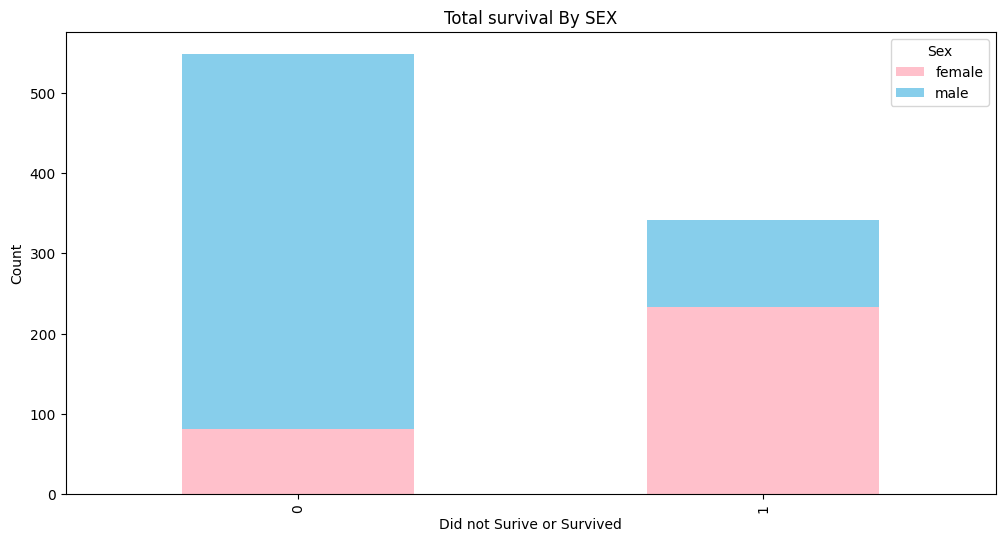

In [5]:

counts=df.groupby(['Survived','Sex']).size()
counts.unstack().plot(kind='bar',figsize=(12,6),color=['pink','skyblue'],stacked=True)
plt.xlabel( "Did not Surive or Survived")
plt.ylabel('Count')
plt.title("Total survival By SEX")
plt.show()



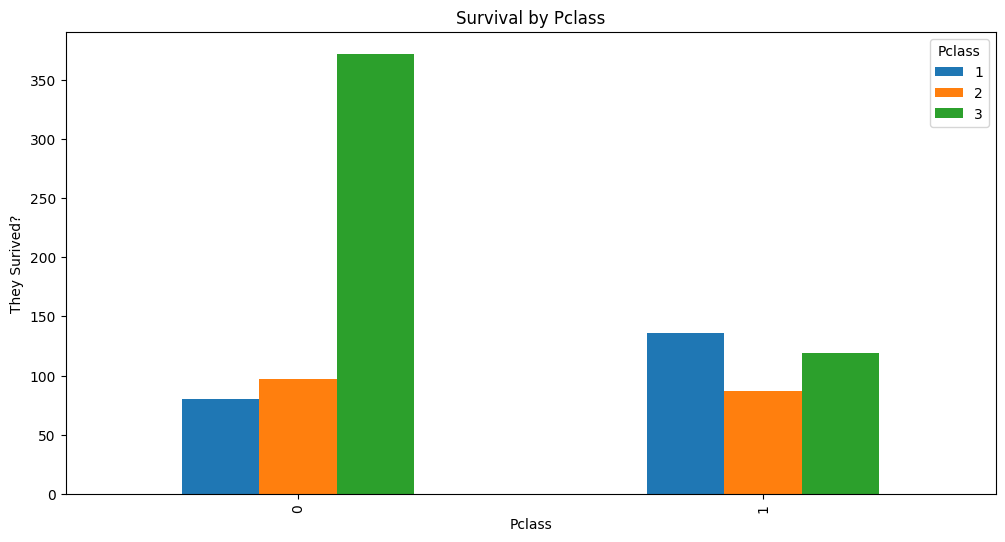

In [6]:

# we can see most of the Pclass:3 died and almost half of both Pclass:1(most) and 2 survied
counts=df.groupby(['Survived','Pclass']).size()
counts.unstack().plot(kind="bar",figsize=(12,6))
plt.xlabel("Pclass")
plt.ylabel("They Surived?")
plt.title("Survival by Pclass")
plt.show()

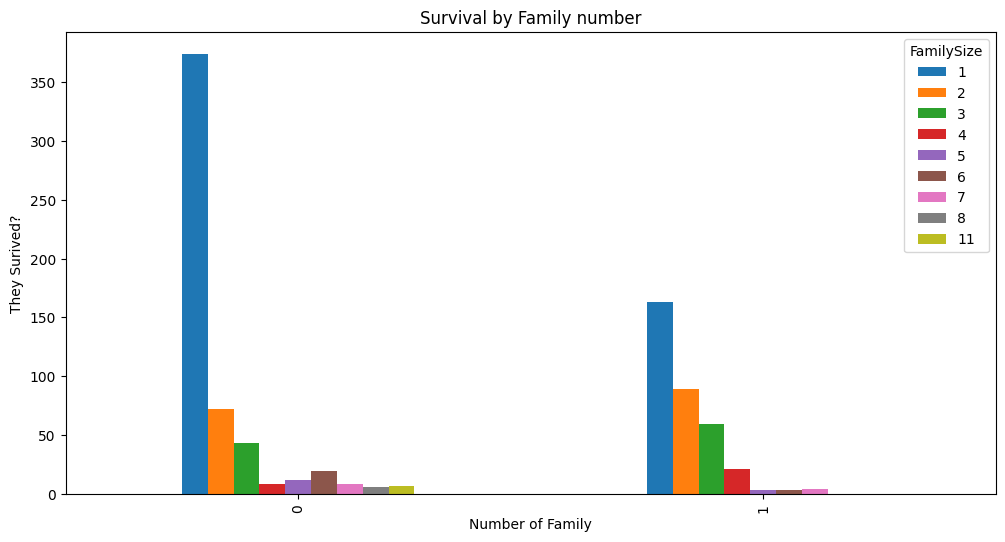

In [7]:
df['FamilySize']=df['SibSp']+df['Parch']+1
counts=df.groupby(['Survived','FamilySize']).size()
counts.unstack().plot(kind="bar",figsize=(12,6))
plt.xlabel("Number of Family")
plt.ylabel("They Surived?")
plt.title("Survival by Family number")
plt.show()

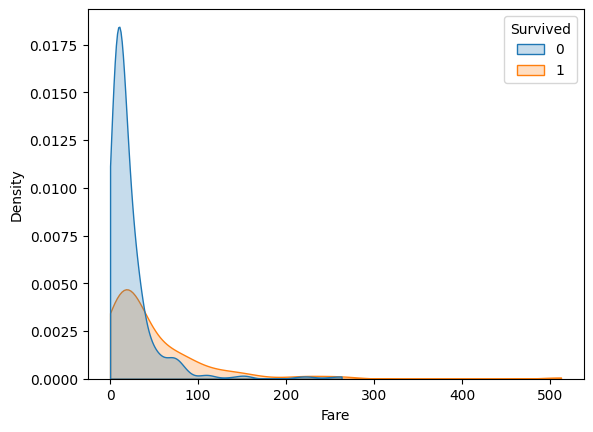

In [8]:
sns.kdeplot(data=df, x='Fare', hue='Survived', fill=True,cut=0)
plt.xlabel('Fare')
plt.show()

In [36]:
encoder=OneHotEncoder(sparse_output=False,drop='first')
df['Sex']=encoder.fit_transform(df[['Sex']])
scaler=StandardScaler()
df['Fare']=scaler.fit_transform(df[['Fare']])
df['Age']=scaler.fit_transform(df[['Age']])


features=["Age","Fare","FamilySize","Pclass","Sex"]

X=df.loc[:,features].values
Y=df.loc[:,"Survived"].values

model=LogisticRegression(iteration=5000,learning_rate=0.04)
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
model.fit(x_train,y_train)

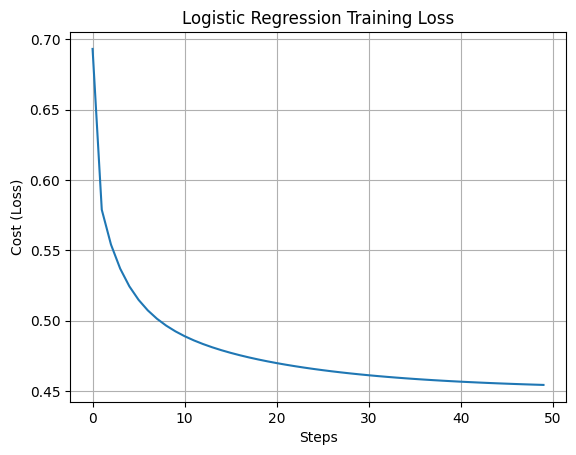

In [37]:
X=model.Loss()
plt.figure()
plt.plot(X)
plt.xlabel("Steps")
plt.ylabel("Cost (Loss)")
plt.grid(True)
plt.title("Logistic Regression Training Loss")
plt.show()

In [38]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

accuracy=accuracy_score(y_test,model.predict(x_test))
r2=r2_score(y_test,model.predict(x_test))
print("Accuracy Score: ",accuracy*100)


Accuracy Score:  80.44692737430168
